# Swapped molecule removal

#### Pijuan-Sala, Griffiths, Guibentif et al.: A single-cell resolution molecular roadmap from mouse gastrulation to early organogenesis.

11 August 2018
In this script, we exclude molecules that are likely to have derived from barcode swapping. In short, we identify molecules that share UMI, cell barcode, and aligned gene between samples that were sequenced together. These molecules are extremely unlikely to have arisen due to chance, and are instead far more likely to derive from barcode swapping. For more information on this phenomenon, please read our paper. Figure 1 shows the fraction of molecules that were excluded, on a sample-by-sample basis.

In [2]:
suppressPackageStartupMessages({
    library(DropletUtils)
    library(ggplot2)
    library(cowplot)
    library(Matrix)
})

### Change only this:
main = '/rds/project/rds-SDzz0CATGms/users/bt392/01_Eomes_RNA/SLX-20795_fastq/'
subfolders = paste0(main, 'SLX-20795_SITT', c('A11', 'A12', 'B11', 'F11', 'G10', 'G11', 'H10', 'H11'), '_HKTG2DRXY/')

out_dir = '/rds/project/rds-SDzz0CATGms/users/bt392/01_Eomes_RNA/01_index_correction/'
out_subfolders = paste0(out_dir, 'SLX-20795_SITT', c('A11', 'A12', 'B11', 'F11', 'G10', 'G11', 'H10', 'H11'), '_HKTG2DRXY/')

nr_samples = 8

###

dir.create(out_dir, showWarnings = FALSE)
for(i in 1:length(out_subfolders)){
    dir.create(out_subfolders[i], showWarnings = FALSE)
}


mol_loc = paste0(subfolders, "outs/molecule_info.h5")

out_loc = paste0(out_subfolders, "matrix_unswapped.mtx")
bc_loc = paste0(out_subfolders, "barcodes_unswapped.tsv")
gene_loc = paste0(out_subfolders, "genes_unswapped.tsv")

unswapped = swappedDrops(mol_loc, get.swapped = TRUE)

ratios = sapply(1:length(unswapped$cleaned), function(i){
  sum(unswapped$swapped[[i]])/(sum(unswapped$cleaned[[i]]) + sum(unswapped$swapped[[i]]))
})

for(i in 1:length(mol_loc)){
  null_holder = writeMM(unswapped$cleaned[[i]], file = out_loc[i])
  write.table(colnames(unswapped$cleaned[[i]]), file = bc_loc[i], col.names = FALSE, row.names = FALSE, quote = FALSE)
  write.table(rownames(unswapped$cleaned[[i]]), file = gene_loc[i], col.names = FALSE, row.names = FALSE, quote = FALSE)
}

In [7]:
ratios

[1] 0.0004243418 0.0003638783 0.0003677825 0.0002864429 0.0004987467
[6] 0.0003201050 0.0004814373 0.0003187587

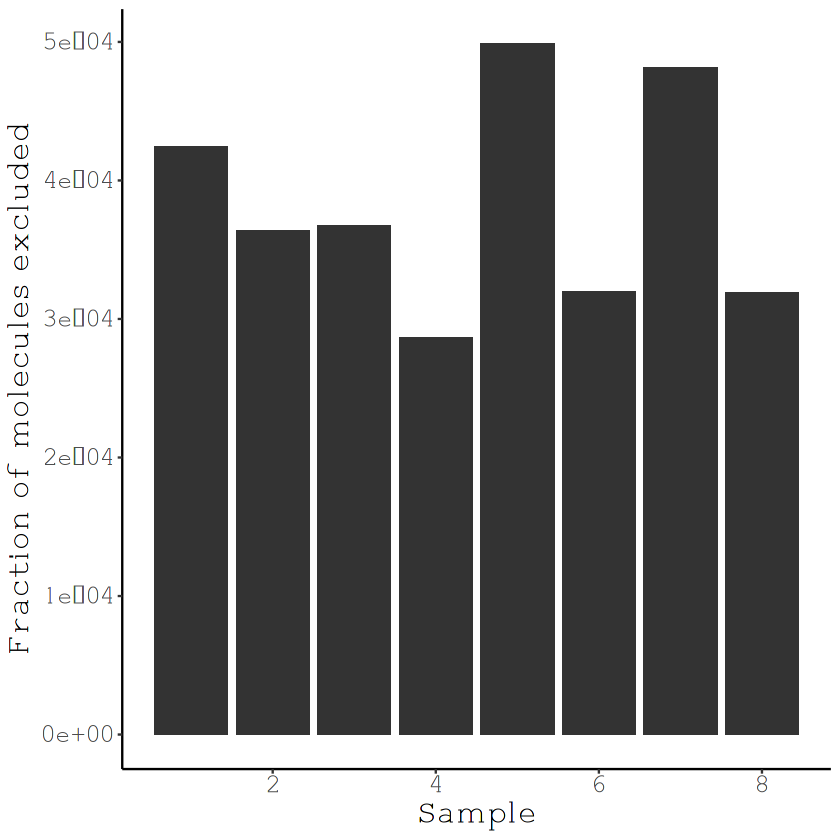

In [6]:
ggplot(data.frame(ratios = ratios, sample = 1:nr_samples), aes(x = sample, y = ratios)) +
  geom_bar(stat = "identity", fill = "grey20") +
  labs(x = "Sample", y = "Fraction of molecules excluded") +
  theme_classic() + 
  theme(text = element_text(size=20)) 

In [36]:
sessionInfo()

R version 4.0.3 (2020-10-10)
Platform: x86_64-pc-linux-gnu (64-bit)
Running under: Manjaro Linux

Matrix products: default
BLAS:   /usr/local/lib64/R/lib/libRblas.so
LAPACK: /usr/local/lib64/R/lib/libRlapack.so

locale:
 [1] LC_CTYPE=en_GB.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_GB.UTF-8        LC_COLLATE=en_GB.UTF-8    
 [5] LC_MONETARY=en_GB.UTF-8    LC_MESSAGES=en_GB.UTF-8   
 [7] LC_PAPER=en_GB.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_GB.UTF-8 LC_IDENTIFICATION=C       

attached base packages:
[1] parallel  stats4    stats     graphics  grDevices utils     datasets 
[8] methods   base     

other attached packages:
 [1] Matrix_1.2-18               cowplot_1.1.1              
 [3] ggplot2_3.3.3               DropletUtils_1.10.0        
 [5] SingleCellExperiment_1.12.0 SummarizedExperiment_1.20.0
 [7] Biobase_2.50.0              GenomicRanges_1.42.0       
 [9] GenomeInfoDb_1.26.2         